Using final-results workbook: D:\Headway\final run\tables\T6_Final_AFT_Bootstrap_CoxSnell.xlsx

Refit audit:
                Pair      Distribution  Reported logLik  Refitted logLik  Absolute difference
    BTW_following_4W Generalized gamma      -276.443102      -276.443102                  0.0
 BTW_following_MT_3W  Inverse Gaussian      -186.730248      -186.730248                  0.0
BTW_following_NMT_3W             Gamma      -143.955713      -143.955713                  0.0
 BTW_following_MT_2W             Gamma       -75.323137       -75.323137                  0.0
BTW_following_NMT_2W  Inverse Gaussian       -40.242033       -40.242033                  0.0
     PR_following_4W Generalized gamma       -62.216366       -62.216366                  0.0
  PR_following_MT_3W           Weibull      -128.283918      -128.283918                  0.0


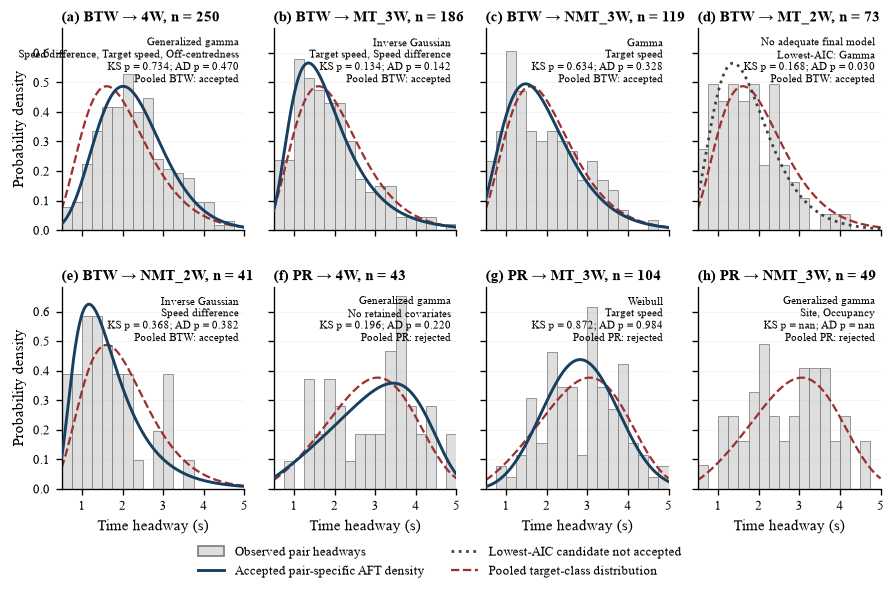


Saved:
D:\Headway\Graphics\F_Final_pairwise_AFT_vs_pooled.png
D:\Headway\Graphics\F_Final_pairwise_AFT_vs_pooled.pdf


In [3]:
# =============================================================================
# FINAL FIGURE:
# Observed pair-specific histogram versus final AFT density and pooled reference
# =============================================================================

import os
import glob
import zlib
import warnings

import numpy as np
import pandas as pd
from scipy import stats, optimize

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------------
# 1. Paths
# -------------------------------------------------------------------------
BASE = r"D:\Headway"
DATA = os.path.join(BASE, "data3.xlsx")
TABLES = os.path.join(BASE, "Tables")
GRAPHS = os.path.join(BASE, "Graphics")

os.makedirs(GRAPHS, exist_ok=True)

# Set an explicit path here when preferred.
# When left as None, the code searches TABLES for the workbook containing
# the final S3, S5 and S8 result sheets.
RESULTS = r"D:\Headway\final run\tables\T6_Final_AFT_Bootstrap_CoxSnell.xlsx"

REQUIRED_SHEETS = {
    "S3_AFT_final_GOF",
    "S5_Final_decisions",
    "S8_Pooled_GOF",
}


def find_results_workbook(folder):
    candidates = sorted(
        glob.glob(os.path.join(folder, "*.xlsx")),
        key=os.path.getmtime,
        reverse=True,
    )

    for path in candidates:
        try:
            sheets = set(pd.ExcelFile(path).sheet_names)
            if REQUIRED_SHEETS.issubset(sheets):
                return path
        except Exception:
            continue

    raise FileNotFoundError(
        "No workbook containing S3_AFT_final_GOF, "
        "S5_Final_decisions and S8_Pooled_GOF was found. "
        "Set RESULTS to the correct file path."
    )


if RESULTS is None:
    RESULTS = find_results_workbook(TABLES)

print("Using final-results workbook:", RESULTS)

# -------------------------------------------------------------------------
# 2. Read raw data and final-result sheets
# -------------------------------------------------------------------------
df = pd.read_excel(DATA)

decisions = pd.read_excel(
    RESULTS,
    sheet_name="S5_Final_decisions",
)

final_gof = pd.read_excel(
    RESULTS,
    sheet_name="S3_AFT_final_GOF",
)

pooled_gof = pd.read_excel(
    RESULTS,
    sheet_name="S8_Pooled_GOF",
)

TH = "Time_Headway"

# -------------------------------------------------------------------------
# 3. Distribution definitions
# -------------------------------------------------------------------------
# floc0: location fixed at zero
# free:  Pearson type III has a free location parameter

DISTS = {
    "gengamma": (
        "Generalized gamma",
        stats.gengamma,
        "floc0",
    ),
    "weibull_min": (
        "Weibull",
        stats.weibull_min,
        "floc0",
    ),
    "gamma": (
        "Gamma",
        stats.gamma,
        "floc0",
    ),
    "lognorm": (
        "Log-normal",
        stats.lognorm,
        "floc0",
    ),
    "invgauss": (
        "Inverse Gaussian",
        stats.invgauss,
        "floc0",
    ),
    "pearson3": (
        "Pearson type III",
        stats.pearson3,
        "free",
    ),
}

CONTINUOUS = {
    "Target_Speed_km/hr",
    "Leading_Speed_km/hr",
    "Speed_Difference",
    "Flow_pcu/hr/m",
}

BINARY = {
    "Off_centeredness",
    "Occupancy",
}

COVARIATE_LABELS = {
    "Target_Speed_km/hr": "Target speed",
    "Leading_Speed_km/hr": "Leader speed",
    "Speed_Difference": "Speed difference",
    "Flow_pcu/hr/m": "Traffic pressure",
    "Off_centeredness": "Off-centredness",
    "Occupancy": "Occupancy",
    "Site": "Site",
}

# -------------------------------------------------------------------------
# 4. Identify the model to display for each pair
# -------------------------------------------------------------------------
# Accepted pairs use the distribution selected in S5.
# Unresolved pairs use the lowest-AIC row only as a diagnostic candidate.

plot_rows = []

for _, decision in decisions.iterrows():
    pair = decision["Pair"]
    selected_distribution = decision["Selected distribution"]

    if pd.notna(selected_distribution):
        match = final_gof[
            (final_gof["Pair"] == pair)
            & (final_gof["Distribution"] == selected_distribution)
        ]

        if len(match) != 1:
            raise ValueError(
                f"Could not uniquely locate the selected model for {pair}."
            )

        row = match.iloc[0].copy()
        row["Figure status"] = "Accepted final model"

    else:
        match = final_gof[
            (final_gof["Pair"] == pair)
            & (final_gof["Fit role"] == "Best")
        ]

        if len(match) != 1:
            raise ValueError(
                f"Could not uniquely locate the lowest-AIC model for {pair}."
            )

        row = match.iloc[0].copy()
        row["Figure status"] = "No adequate final model"

    plot_rows.append(row)

models = pd.DataFrame(plot_rows)

PAIR_ORDER = [
    "BTW_following_4W",
    "BTW_following_MT_3W",
    "BTW_following_NMT_3W",
    "BTW_following_MT_2W",
    "BTW_following_NMT_2W",
    "PR_following_4W",
    "PR_following_MT_3W",
    "PR_following_NMT_3W",
]

models["Figure order"] = models["Pair"].map(
    {pair: i for i, pair in enumerate(PAIR_ORDER)}
)

models = models.sort_values("Figure order").reset_index(drop=True)

# -------------------------------------------------------------------------
# 5. Data coding and within-pair standardization
# -------------------------------------------------------------------------
def convert_binary(series):
    """Convert bool, 0/1 or text-coded binary data to float."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype(float).to_numpy()

    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float).to_numpy()

    mapped = (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({
            "true": 1.0,
            "false": 0.0,
            "yes": 1.0,
            "no": 0.0,
            "1": 1.0,
            "0": 0.0,
        })
    )

    if mapped.isna().any():
        raise ValueError(
            f"Unrecognized binary values in {series.name}: "
            f"{series[mapped.isna()].unique()}"
        )

    return mapped.to_numpy(dtype=float)


def parse_covariates(covariate_text):
    if (
        pd.isna(covariate_text)
        or str(covariate_text).strip() in {"", "(none)", "None"}
    ):
        return []

    return [
        value.strip()
        for value in str(covariate_text).split(",")
        if value.strip()
    ]


def construct_covariate_matrix(pair_data, covariates):
    """
    Continuous variables are standardized within the target-leader pair.
    Binary variables are coded 0/1.
    Site: Shahjahanpur = 0, Tikatuli = 1.
    """
    if not covariates:
        return np.zeros((len(pair_data), 0), dtype=float)

    columns = []

    for covariate in covariates:
        if covariate in CONTINUOUS:
            values = pair_data[covariate].astype(float).to_numpy()
            sd = np.std(values, ddof=1)

            if not np.isfinite(sd) or sd <= 0:
                raise ValueError(
                    f"{covariate} is not estimable within "
                    f"{pair_data['Pair'].iloc[0]}."
                )

            standardized = (
                values - np.mean(values)
            ) / sd

            columns.append(standardized)

        elif covariate in BINARY:
            columns.append(
                convert_binary(pair_data[covariate])
            )

        elif covariate == "Site":
            site = (
                pair_data["Site"]
                .astype(str)
                .str.strip()
            )

            columns.append(
                (site == "Tikatuli").astype(float).to_numpy()
            )

        else:
            raise KeyError(
                f"Covariate {covariate!r} is not defined."
            )

    return np.column_stack(columns).astype(float)

# -------------------------------------------------------------------------
# 6. Baseline and AFT likelihood functions
# -------------------------------------------------------------------------
def fit_baseline_parameters(distribution_key, x):
    _, distribution, mode = DISTS[distribution_key]

    if mode == "free":
        parameters = distribution.fit(x)
    else:
        parameters = distribution.fit(x, floc=0.0)

    return np.asarray(parameters, dtype=float)


def aft_negative_loglikelihood(
    theta,
    distribution_key,
    x,
    Z,
    n_shape,
):
    _, distribution, mode = DISTS[distribution_key]

    shape_parameters = theta[:n_shape]

    if mode == "free":
        location = theta[n_shape]
        scale = theta[n_shape + 1]
        beta = theta[n_shape + 2:]
    else:
        location = 0.0
        scale = theta[n_shape]
        beta = theta[n_shape + 1:]

    if not np.isfinite(scale) or scale <= 0:
        return 1.0e100

    eta = (
        Z @ beta
        if Z.shape[1] > 0
        else np.zeros(len(x), dtype=float)
    )

    try:
        transformed_headway = x * np.exp(-eta)

        log_density = (
            distribution.logpdf(
                transformed_headway,
                *shape_parameters,
                loc=location,
                scale=scale,
            )
            - eta
        )

    except Exception:
        return 1.0e100

    if not np.all(np.isfinite(log_density)):
        return 1.0e100

    return -float(np.sum(log_density))


def parameter_bounds(
    distribution_key,
    x,
    n_shape,
    n_covariates,
):
    _, _, mode = DISTS[distribution_key]

    if distribution_key == "gengamma":
        shape_bounds = [
            (1.0e-7, 1000.0),
            (1.0e-7, 1000.0),
        ]

    elif distribution_key == "pearson3":
        shape_bounds = [
            (-50.0, 50.0)
            for _ in range(n_shape)
        ]

    else:
        shape_bounds = [
            (1.0e-7, 100.0)
            for _ in range(n_shape)
        ]

    scale_upper = max(
        100.0,
        20.0 * float(np.max(x)),
    )

    if mode == "free":
        sd = float(np.std(x, ddof=1))

        location_bounds = (
            float(np.min(x) - 10.0 * sd),
            float(np.max(x) + 10.0 * sd),
        )

        return (
            shape_bounds
            + [location_bounds]
            + [(1.0e-7, scale_upper)]
            + [(-5.0, 5.0)] * n_covariates
        )

    return (
        shape_bounds
        + [(1.0e-7, scale_upper)]
        + [(-5.0, 5.0)] * n_covariates
    )


def fit_aft_model(
    distribution_key,
    x,
    Z,
    pair,
    reference_loglik=None,
    number_of_starts=10,
):
    """
    Multiple-start bounded L-BFGS-B fit.
    Powell is used as a fallback when necessary.
    """
    _, _, mode = DISTS[distribution_key]

    baseline = fit_baseline_parameters(
        distribution_key,
        x,
    )

    n_shape = len(baseline) - 2
    n_covariates = Z.shape[1]

    if mode == "free":
        initial = np.concatenate([
            baseline[:n_shape],
            [baseline[-2], baseline[-1]],
            np.zeros(n_covariates),
        ])
    else:
        initial = np.concatenate([
            baseline[:n_shape],
            [baseline[-1]],
            np.zeros(n_covariates),
        ])

    bounds = parameter_bounds(
        distribution_key,
        x,
        n_shape,
        n_covariates,
    )

    seed = (
        20260731
        + zlib.crc32(
            f"{pair}|{distribution_key}".encode("utf-8")
        )
    )

    rng = np.random.default_rng(seed)

    starts = [initial.copy()]

    for _ in range(number_of_starts - 1):
        trial = initial.copy()

        for j, (lower, upper) in enumerate(bounds):
            if lower >= 0:
                trial[j] = np.clip(
                    trial[j]
                    * np.exp(rng.normal(0.0, 0.15)),
                    lower + 1.0e-9,
                    upper - 1.0e-9,
                )
            else:
                trial[j] = np.clip(
                    trial[j] + rng.normal(0.0, 0.15),
                    lower + 1.0e-9,
                    upper - 1.0e-9,
                )

        starts.append(trial)

    best = None

    for start in starts:
        result = optimize.minimize(
            aft_negative_loglikelihood,
            start,
            args=(
                distribution_key,
                x,
                Z,
                n_shape,
            ),
            method="L-BFGS-B",
            bounds=bounds,
            options={
                "maxiter": 50000,
                "ftol": 1.0e-12,
                "gtol": 1.0e-8,
                "maxls": 50,
            },
        )

        if (
            np.isfinite(result.fun)
            and (
                best is None
                or result.fun < best.fun
            )
        ):
            best = result

    # Powell fallback
    needs_fallback = (
        best is None
        or not np.isfinite(best.fun)
    )

    if (
        reference_loglik is not None
        and best is not None
        and abs((-best.fun) - reference_loglik) > 1.0e-3
    ):
        needs_fallback = True

    if needs_fallback:
        result = optimize.minimize(
            aft_negative_loglikelihood,
            initial,
            args=(
                distribution_key,
                x,
                Z,
                n_shape,
            ),
            method="Powell",
            bounds=bounds,
            options={
                "maxiter": 50000,
                "ftol": 1.0e-12,
                "xtol": 1.0e-10,
            },
        )

        if (
            np.isfinite(result.fun)
            and (
                best is None
                or result.fun < best.fun
            )
        ):
            best = result

    if best is None or not np.isfinite(best.fun):
        raise RuntimeError(
            f"AFT fitting failed for {pair}, "
            f"{distribution_key}."
        )

    loglik = -float(best.fun)

    if (
        reference_loglik is not None
        and abs(loglik - reference_loglik) > 1.0e-2
    ):
        warnings.warn(
            f"{pair}: refitted log-likelihood "
            f"({loglik:.6f}) differs from the reported value "
            f"({reference_loglik:.6f})."
        )

    return {
        "theta": np.asarray(best.x, dtype=float),
        "logLik": loglik,
        "n_shape": n_shape,
        "success": bool(best.success),
        "optimizer_message": str(best.message),
    }

# -------------------------------------------------------------------------
# 7. Marginal density implied by the conditional AFT model
# -------------------------------------------------------------------------
def average_aft_density(
    grid,
    distribution_key,
    fitted_model,
    Z,
):
    """
    Average conditional density:

      f_bar(t) = n^-1 sum_i exp(-eta_i)
                 f0[t exp(-eta_i)]

    This is the appropriate curve to compare with the raw pair histogram.
    """
    _, distribution, mode = DISTS[distribution_key]

    theta = fitted_model["theta"]
    n_shape = fitted_model["n_shape"]

    shape_parameters = theta[:n_shape]

    if mode == "free":
        location = theta[n_shape]
        scale = theta[n_shape + 1]
        beta = theta[n_shape + 2:]
    else:
        location = 0.0
        scale = theta[n_shape]
        beta = theta[n_shape + 1:]

    eta = (
        Z @ beta
        if Z.shape[1] > 0
        else np.zeros(Z.shape[0], dtype=float)
    )

    acceleration = np.exp(-eta)

    transformed_grid = (
        acceleration[:, None]
        * grid[None, :]
    )

    conditional_density = (
        acceleration[:, None]
        * distribution.pdf(
            transformed_grid,
            *shape_parameters,
            loc=location,
            scale=scale,
        )
    )

    conditional_density[
        ~np.isfinite(conditional_density)
    ] = np.nan

    return np.nanmean(
        conditional_density,
        axis=0,
    )

# -------------------------------------------------------------------------
# 8. Fit the pooled target-class reference distributions
# -------------------------------------------------------------------------
pooled_models = {}

for target in ["BTW", "PR"]:
    pooled_row = pooled_gof[
        (pooled_gof["Pooled group"] == target)
        & (pooled_gof["Fit role"] == "Best")
    ]

    if len(pooled_row) != 1:
        raise ValueError(
            f"Could not locate the pooled best model for {target}."
        )

    pooled_row = pooled_row.iloc[0]

    pooled_key = pooled_row["Distribution key"]

    pooled_x = (
        df.loc[
            df["V_Target"] == target,
            TH,
        ]
        .astype(float)
        .to_numpy()
    )

    pooled_parameters = fit_baseline_parameters(
        pooled_key,
        pooled_x,
    )

    pooled_models[target] = {
        "row": pooled_row,
        "key": pooled_key,
        "parameters": pooled_parameters,
    }

# -------------------------------------------------------------------------
# 9. Refit the pair-specific models needed for the figure
# -------------------------------------------------------------------------
fitted_pair_models = {}
audit_rows = []

for _, row in models.iterrows():
    pair = row["Pair"]
    distribution_key = row["Distribution key"]
    bootstrap_status = str(row["Bootstrap status"])

    pair_data = (
        df.loc[df["Pair"] == pair]
        .copy()
        .reset_index(drop=True)
    )

    x = (
        pair_data[TH]
        .astype(float)
        .to_numpy()
    )

    covariates = parse_covariates(
        row["Final covariates"]
    )

    Z = construct_covariate_matrix(
        pair_data,
        covariates,
    )

    # The PR -> NMT_3W model had no valid bootstrap replicates
    # and is deliberately not drawn as a fitted final curve.
    if bootstrap_status.startswith(
        "INSUFFICIENT VALID REPLICATES"
    ):
        fitted_pair_models[pair] = None
        continue

    fitted = fit_aft_model(
        distribution_key=distribution_key,
        x=x,
        Z=Z,
        pair=pair,
        reference_loglik=float(row["logLik"]),
    )

    fitted_pair_models[pair] = {
        "fit": fitted,
        "Z": Z,
        "covariates": covariates,
    }

    audit_rows.append({
        "Pair": pair,
        "Distribution": row["Distribution"],
        "Reported logLik": float(row["logLik"]),
        "Refitted logLik": fitted["logLik"],
        "Absolute difference": abs(
            fitted["logLik"]
            - float(row["logLik"])
        ),
    })

audit = pd.DataFrame(audit_rows)

print("\nRefit audit:")
print(
    audit.round(8).to_string(index=False)
)

# -------------------------------------------------------------------------
# 10. Journal-style plotting
# -------------------------------------------------------------------------
for font_name in [
    "Times New Roman",
    "Nimbus Roman",
    "DejaVu Serif",
]:
    available = [
        font.name.lower()
        for font in mpl.font_manager.fontManager.ttflist
    ]

    if any(
        font_name.lower() in name
        for name in available
    ):
        SERIF = font_name
        break
else:
    SERIF = "serif"

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": [SERIF],
    "font.size": 8.5,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.fontsize": 8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# Consistent bins are preferable for comparing panels.
bins = np.arange(
    0.50,
    5.0001,
    0.25,
)

grid = np.linspace(
    0.50,
    5.00,
    600,
)

fig, axes = plt.subplots(
    2,
    4,
    figsize=(7.5, 4.8),
    sharex=True,
    sharey=True,
)

axes = axes.ravel()

for panel_number, pair in enumerate(PAIR_ORDER):
    ax = axes[panel_number]

    row = models.loc[
        models["Pair"] == pair
    ].iloc[0]

    pair_data = df.loc[
        df["Pair"] == pair
    ].copy()

    x = (
        pair_data[TH]
        .astype(float)
        .to_numpy()
    )

    target = str(row["Target"])
    distribution_key = row["Distribution key"]
    distribution_label = row["Distribution"]

    is_adequate = bool(
        row["Accepted by both tests"]
    )

    bootstrap_status = str(
        row["Bootstrap status"]
    )

    # Observed pair histogram
    ax.hist(
        x,
        bins=bins,
        density=True,
        facecolor="0.87",
        edgecolor="0.48",
        linewidth=0.45,
        zorder=1,
    )

    # Pooled target-class reference
    pooled = pooled_models[target]
    pooled_key = pooled["key"]
    _, pooled_distribution, _ = DISTS[pooled_key]

    pooled_density = pooled_distribution.pdf(
        grid,
        *pooled["parameters"],
    )

    ax.plot(
        grid,
        pooled_density,
        linestyle="--",
        linewidth=1.35,
        color="#9C2F2F",
        zorder=2,
    )

    # Accepted AFT model or rejected diagnostic candidate
    pair_fit = fitted_pair_models.get(pair)

    if pair_fit is not None:
        pair_density = average_aft_density(
            grid=grid,
            distribution_key=distribution_key,
            fitted_model=pair_fit["fit"],
            Z=pair_fit["Z"],
        )

        if is_adequate:
            ax.plot(
                grid,
                pair_density,
                linestyle="-",
                linewidth=1.75,
                color="#173F5F",
                zorder=3,
            )
        else:
            ax.plot(
                grid,
                pair_density,
                linestyle=":",
                linewidth=1.65,
                color="0.25",
                zorder=3,
            )

    # Panel title
    pair_label = pair.replace(
        "_following_",
        " \u2192 ",
    )

    panel_letter = chr(
        ord("a") + panel_number
    )

    ax.set_title(
        f"({panel_letter}) {pair_label}, n = {len(x)}",
        loc="left",
        fontweight="bold",
        pad=4,
    )

    # Covariate description
    covariates = parse_covariates(
        row["Final covariates"]
    )

    if covariates:
        covariate_text = ", ".join(
            COVARIATE_LABELS.get(c, c)
            for c in covariates
        )
    else:
        covariate_text = "No retained covariates"

    pooled_row = pooled["row"]
    pooled_accepted = bool(
        pooled_row["Accepted by both tests"]
    )

    pooled_status = (
        "accepted"
        if pooled_accepted
        else "rejected"
    )

    if is_adequate:
        status_text = (
            f"{distribution_label}\n"
            f"{covariate_text}\n"
            f"KS p = {row['KS bootstrap p']:.3f}; "
            f"AD p = {row['AD bootstrap p']:.3f}\n"
            f"Pooled {target}: {pooled_status}"
        )

    elif bootstrap_status == "OK":
        status_text = (
            f"No adequate final model\n"
            f"Lowest-AIC: {distribution_label}\n"
            f"KS p = {row['KS bootstrap p']:.3f}; "
            f"AD p = {row['AD bootstrap p']:.3f}\n"
            f"Pooled {target}: {pooled_status}"
        )

    else:
        status_text = (
            f"No adequate final model\n"
            f"Lowest-AIC: {distribution_label}\n"
            f"Final bootstrap invalid\n"
            f"Pooled {target}: {pooled_status}"
        )

    ax.text(
        0.97,
        0.96,
        status_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=6.5,
        linespacing=1.25,
    )

    ax.set_xlim(
        0.50,
        5.00,
    )

    ax.xaxis.set_major_locator(
        MultipleLocator(1.0)
    )

    ax.grid(
        axis="y",
        linewidth=0.35,
        alpha=0.20,
    )

    if panel_number % 4 == 0:
        ax.set_ylabel(
            "Probability density"
        )

    if panel_number >= 4:
        ax.set_xlabel(
            "Time headway (s)"
        )

# -------------------------------------------------------------------------
# 11. Shared figure legend
# -------------------------------------------------------------------------
legend_handles = [
    Patch(
        facecolor="0.87",
        edgecolor="0.48",
        label="Observed pair headways",
    ),
    Line2D(
        [0],
        [0],
        color="#173F5F",
        linewidth=1.75,
        linestyle="-",
        label="Accepted pair-specific AFT density",
    ),
    Line2D(
        [0],
        [0],
        color="0.25",
        linewidth=1.65,
        linestyle=":",
        label="Lowest-AIC candidate not accepted",
    ),
    Line2D(
        [0],
        [0],
        color="#9C2F2F",
        linewidth=1.35,
        linestyle="--",
        label="Pooled target-class distribution",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.015),
    ncol=2,
    frameon=False,
)

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    top=0.96,
    bottom=0.16,
    wspace=0.16,
    hspace=0.28,
)

png_path = os.path.join(
    GRAPHS,
    "F_Final_pairwise_AFT_vs_pooled.png",
)

pdf_path = os.path.join(
    GRAPHS,
    "F_Final_pairwise_AFT_vs_pooled.pdf",
)

fig.savefig(
    png_path,
    dpi=600,
)

fig.savefig(
    pdf_path,
)

plt.show()

print("\nSaved:")
print(png_path)
print(pdf_path)